# Tier 1 Evaluation: Training & Reconstruction Performance

In [1]:
# Purpose:
#   Evaluates the technical performance of a trained β-VAE on DNA methylation
#   M-value profiles. This tier is strictly quantitative — it asks how well the
#   model reconstructs its inputs and whether training converged cleanly. It
#   does not make biological claims; it establishes the technical baseline that
#   all subsequent tiers depend on.
#
# Sections:
#   1.1  Environment Setup & Model Loading
#   1.2  Training Curve Analysis
#   1.3  Global Reconstruction Fidelity
#   1.4  Per-Sample Reconstruction Error
#   1.5  Per-Probe Reconstruction Error
#   1.6  M-Value Distribution Fidelity
#   1.7  Bimodality Preservation
#   1.8  Methylation State Confusion Matrix
#   1.9  β (KL Weight) Annealing Schedule
#   1.10 KL Divergence & Posterior Diagnostics
#
# Inputs:
#   - Trained β-VAE checkpoint (.ckpt)
#   - AnnData object (.h5ad) containing M-values in .X and metadata in .obs
#
# Outputs:
#   - Printed summary statistics
#   - Publication-quality figures saved to ./figures/tier1/
#
# How to interpret:
#   Each section contains an INTERPRETATION block explaining what good/bad
#   results look like and what actions to take if results are unexpected.

# 1.1 Environment Setup & Model Loading

In [42]:
import numpy as np
import pandas as pd
import anndata as ad
import wandb
import torch
import diptest
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, wasserstein_distance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from MethylCDM.models.betaVAE import BetaVAE

In [9]:
# Modify these paths to match your environment
CKPT_PATH   = "/ddn_exa/campbell/sli/methylcdm-project/models/beta_vae/betaVAE_sweep_20260318_141012/trial_1/best-epoch=156-val_loss=1.4227.ckpt"
ADATA_PATH  = "/ddn_exa/campbell/sli/methylcdm-project/data/training/methylation/pancancer_cohort_adata.h5ad"
FIGURES_DIR = Path("/ddn_exa/campbell/sli/methylcdm-project/plots/eval_recon/")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
 
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE  = 64     # Adjust based on available RAM/VRAM
CANCER_KEY  = "project_id"   # Column in adata.obs for cancer type labels

In [10]:
# Cancer type colour palette — consistent across all tiers
CANCER_PALETTE = {
    "TCGA-BLCA": "#E05C5C",
    "TCGA-BRCA": "#5B8DB8",
    "TCGA-GBM":  "#4DAF7C",
    "TCGA-HNSC": "#D4A843",
    "TCGA-KIRC": "#9B6BB5",
}

In [29]:
model = BetaVAE.load_from_checkpoint(CKPT_PATH, map_location=DEVICE)
model.eval()
model.to(DEVICE)

print(f"      Model loaded successfully on {DEVICE.upper()}")
print(f"      Latent dim  : {model.hparams.latent_dim}")
print(f"      Input dim   : {model.hparams.input_dim}")
print(f"      Beta (max)  : {model.hparams.beta}")
print(f"      Encoder dims: {model.hparams.encoder_dims}")
print(f"      Decoder dims: {model.hparams.decoder_dims}")

adata = ad.read_h5ad(ADATA_PATH)

      Model loaded successfully on CPU
      Latent dim  : 92
      Input dim   : 225410
      Beta (max)  : 0.0010288923928409013
      Encoder dims: [2048, 512, 128]
      Decoder dims: [512, 2048]


In [13]:
# Forward pass to extract reconstructions and latent codes
X_raw_list    = []
X_hat_list    = []
z_mu_list     = []
z_logvar_list = []
 
X_input = torch.tensor(np.array(adata.X), dtype=torch.float32)
 
with torch.no_grad():
    for start in range(0, X_input.shape[0], BATCH_SIZE):
        batch = X_input[start:start + BATCH_SIZE].to(DEVICE)
        x_hat, mu, logvar = model(batch)
        X_raw_list.append(batch.cpu().numpy())
        X_hat_list.append(x_hat.cpu().numpy())
        z_mu_list.append(mu.cpu().numpy())
        z_logvar_list.append(logvar.cpu().numpy())
 
X_raw    = np.vstack(X_raw_list)      # (N, P) — raw M-values
X_hat    = np.vstack(X_hat_list)      # (N, P) — reconstructed M-values
Z_mu     = np.vstack(z_mu_list)       # (N, L) — posterior means
Z_logvar = np.vstack(z_logvar_list)   # (N, L) — posterior log-variances

In [14]:
# Convert M-values to beta values
def m_to_beta(m: np.ndarray) -> np.ndarray:
    """Convert M-values to beta values. Clips to [0.001, 0.999] for stability."""
    beta = np.power(2, m) / (np.power(2, m) + 1)
    return np.clip(beta, 0.001, 0.999)
 
Beta_raw = m_to_beta(X_raw)
Beta_hat = m_to_beta(X_hat)

# 1.2 Training Curve Analysis

In [ ]:
# Plots total loss, reconstruction loss, KL loss, and beta annealing over the
# course of training using metrics logged by PyTorch Lightning. Reads from a
# CSV exported by Wandb.
#
# INTERPRETATION:
#   GOOD  — Total loss and reconstruction loss decrease smoothly and plateau.
#           Val loss tracks train loss without diverging (no overfitting).
#           KL loss rises during each annealing ramp and stabilises between
#           cycles, confirming the cyclical schedule is working as intended.
#   BAD   — Train/val divergence indicates overfitting to the training cohort.
#           KL loss remaining at zero throughout indicates posterior collapse —
#           the encoder is ignoring the latent space entirely.
#           Oscillating total loss that never plateaus indicates the learning
#           rate or beta_max is too large.

In [20]:
WANDB_NOTEBOOK_NAME = "eval_recon"
api     = wandb.Api()
run     = api.run("sophiamjiali-university-of-toronto/betaVAE_sweep_20260318_141012/runs/8chwtgud")
metrics = run.history(samples=10_000)  # Returns a DataFrame

# Separate train and validation rows (Lightning logs them on different steps)
train_metrics = metrics.dropna(subset=['train_loss']).copy()
val_metrics   = metrics.dropna(subset=['val_loss']).copy()

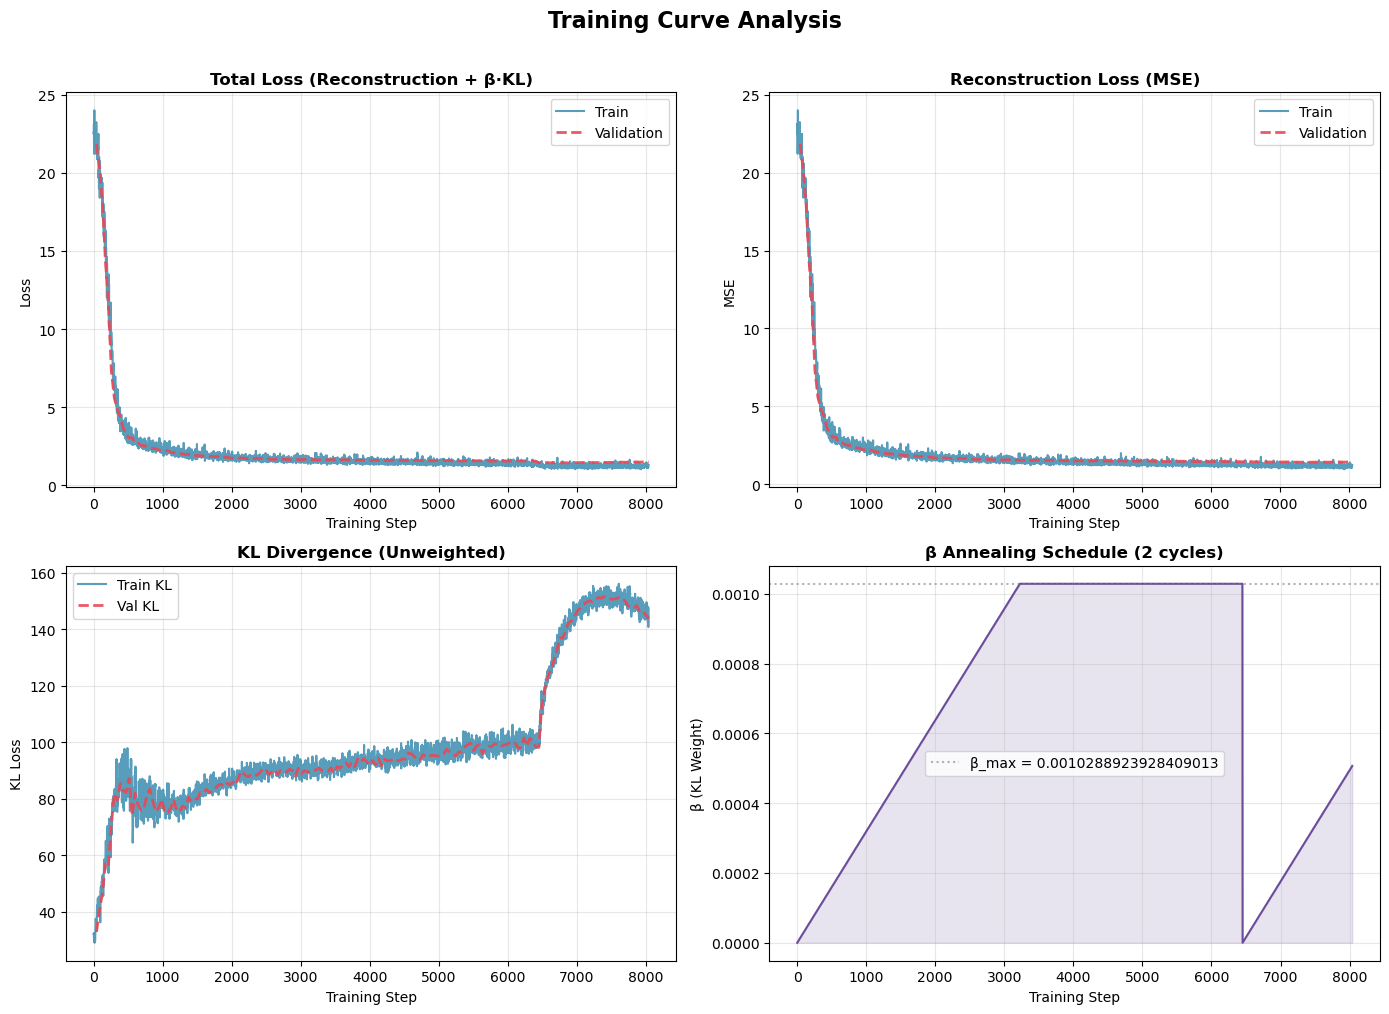

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training Curve Analysis", fontsize=16, fontweight='bold', y=1.01)

# --- Total Loss ---
ax = axes[0, 0]
ax.plot(train_metrics['_step'], train_metrics['train_loss'],
        color='#2E86AB', alpha=0.8, linewidth=1.5, label='Train')
ax.plot(val_metrics['_step'], val_metrics['val_loss'],
        color='#E84855', alpha=0.9, linewidth=2.0, label='Validation', linestyle='--')
ax.set_title("Total Loss (Reconstruction + β·KL)", fontweight='bold')
ax.set_xlabel("Training Step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)

# --- Reconstruction Loss ---
ax = axes[0, 1]
if 'train_recon' in metrics.columns:
    train_recon = metrics.dropna(subset=['train_recon'])
    val_recon   = metrics.dropna(subset=['val_recon'])
    ax.plot(train_recon['_step'], train_recon['train_recon'],
            color='#2E86AB', alpha=0.8, linewidth=1.5, label='Train')
    ax.plot(val_recon['_step'], val_recon['val_recon'],
            color='#E84855', alpha=0.9, linewidth=2.0, label='Validation', linestyle='--')
ax.set_title("Reconstruction Loss (MSE)", fontweight='bold')
ax.set_xlabel("Training Step")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(alpha=0.3)

# --- KL Divergence ---
ax = axes[1, 0]
if 'train_kl' in metrics.columns:
    train_kl = metrics.dropna(subset=['train_kl'])
    val_kl   = metrics.dropna(subset=['val_kl'])
    ax.plot(train_kl['_step'], train_kl['train_kl'],
            color='#2E86AB', alpha=0.8, linewidth=1.5, label='Train KL')
    ax.plot(val_kl['_step'], val_kl['val_kl'],
            color='#E84855', alpha=0.9, linewidth=2.0, label='Val KL', linestyle='--')
ax.set_title("KL Divergence (Unweighted)", fontweight='bold')
ax.set_xlabel("Training Step")
ax.set_ylabel("KL Loss")
ax.legend()
ax.grid(alpha=0.3)

# --- Beta Annealing Schedule ---
ax = axes[1, 1]
if 'beta' in metrics.columns:
    beta_log = metrics.dropna(subset=['beta'])
    ax.plot(beta_log['_step'], beta_log['beta'],
            color='#6B4C9A', linewidth=1.5)
    ax.axhline(model.hparams.beta, color='gray', linestyle=':', alpha=0.6,
               label=f'β_max = {model.hparams.beta}')
    ax.fill_between(beta_log['_step'], 0, beta_log['beta'],
                    alpha=0.15, color='#6B4C9A')
ax.set_title(f"β Annealing Schedule ({model.hparams.num_cycles} cycles)", fontweight='bold')
ax.set_xlabel("Training Step")
ax.set_ylabel("β (KL Weight)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "1_2_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [27]:
final_train = train_metrics.iloc[-1]
final_val   = val_metrics.iloc[-1]
print(f"\n      Final train loss : {final_train.get('train_loss', 'N/A'):.6f}")
print(f"      Final val loss   : {final_val.get('val_loss', 'N/A'):.6f}")
if 'train_loss' in final_train and 'val_loss' in final_val:
    gap = abs(final_val['val_loss'] - final_train['train_loss'])
    print(f"      Train/val gap    : {gap:.6f}  {'[OK]' if gap < 0.01 else '[WARNING: possible overfit]'}")


      Final train loss : 1.303600
      Final val loss   : 1.481648
      Train/val gap    : 0.178048  [WARNING: possible overfit]


# 1.3 Global Reconstruction Fidelity

In [ ]:
# Computes aggregate reconstruction quality metrics across all samples and
# probes: MSE, MAE, Pearson correlation, Spearman correlation, and R².
# Stratified by cancer type to reveal whether the VAE reconstructs some
# cancer types better than others.
#
# INTERPRETATION:
#   GOOD  — Global Pearson r > 0.95 for M-values indicates strong
#           reconstruction. Cancer-type stratified MSE should be relatively
#           uniform — large disparities indicate the VAE is fitting some
#           cancers at the expense of others, which will bias the diffusion
#           model's conditioning.
#   BAD   — Pearson r < 0.90 indicates the VAE is not capturing the
#           majority of variance in the input space.
#           Any cancer type with MSE > 2× the global mean warrants
#           investigation into whether that cancer's methylation
#           distribution falls outside the model's learned manifold.

In [28]:
# --- Global metrics ---
global_mse  = np.mean((X_raw - X_hat) ** 2)
global_mae  = np.mean(np.abs(X_raw - X_hat))
flat_raw    = X_raw.flatten()
flat_hat    = X_hat.flatten()
global_r, global_p     = pearsonr(flat_raw[:500_000], flat_hat[:500_000])  # Subsample for speed
global_rho, global_rho_p = spearmanr(flat_raw[:500_000], flat_hat[:500_000])
ss_res  = np.sum((flat_raw - flat_hat) ** 2)
ss_tot  = np.sum((flat_raw - np.mean(flat_raw)) ** 2)
global_r2   = 1 - (ss_res / ss_tot)
 
print(f"\n  Global Metrics (M-values, all samples × all probes):")
print(f"  {'Metric':<30} {'Value':>12}")
print(f"  {'-'*44}")
print(f"  {'MSE':<30} {global_mse:>12.6f}")
print(f"  {'MAE':<30} {global_mae:>12.6f}")
print(f"  {'Pearson r':<30} {global_r:>12.6f}")
print(f"  {'Spearman ρ':<30} {global_rho:>12.6f}")
print(f"  {'R²':<30} {global_r2:>12.6f}")


  Global Metrics (M-values, all samples × all probes):
  Metric                                Value
  --------------------------------------------
  MSE                                1.223103
  MAE                                0.656961
  Pearson r                          0.959298
  Spearman ρ                         0.965537
  R²                                 0.943542


In [30]:
# --- Per-cancer-type stratified MSE ---
cancer_labels = adata.obs[CANCER_KEY].values
cancer_types  = sorted(adata.obs[CANCER_KEY].unique())
 
cancer_stats = []
for ct in cancer_types:
    idx  = np.where(cancer_labels == ct)[0]
    mse  = np.mean((X_raw[idx] - X_hat[idx]) ** 2)
    mae  = np.mean(np.abs(X_raw[idx] - X_hat[idx]))
    r_flat_raw = X_raw[idx].flatten()
    r_flat_hat = X_hat[idx].flatten()
    sub = min(200_000, len(r_flat_raw))
    r, _ = pearsonr(r_flat_raw[:sub], r_flat_hat[:sub])
    cancer_stats.append({'Cancer Type': ct, 'MSE': mse, 'MAE': mae, 'Pearson r': r, 'N': len(idx)})
 
cancer_df = pd.DataFrame(cancer_stats).set_index('Cancer Type')
print(f"\n  Per-Cancer-Type Reconstruction Metrics:")
print(f"  {cancer_df.round(6).to_string()}")


  Per-Cancer-Type Reconstruction Metrics:
                    MSE       MAE  Pearson r    N
Cancer Type                                    
TCGA-BLCA    1.580164  0.740425   0.977502  408
TCGA-BRCA    1.275737  0.674743   0.959344  756
TCGA-GBM     1.289806  0.691489   0.962347  133
TCGA-HNSC    1.096563  0.615429   0.958468  515
TCGA-KIRC    0.800958  0.556636   0.983145  306


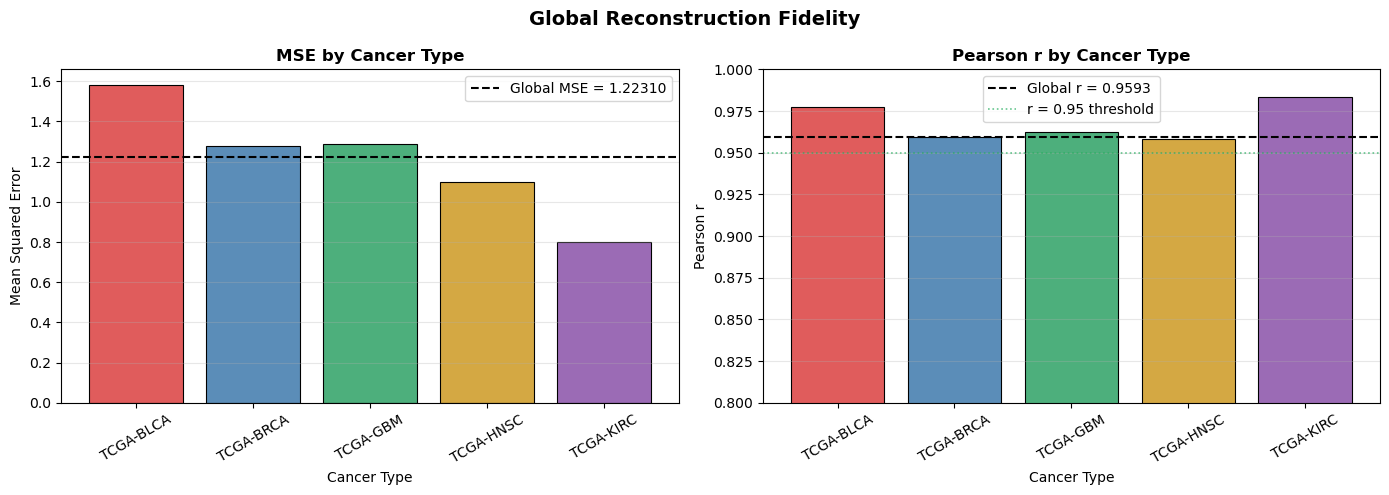


      Figure saved: 1_3_global_reconstruction_fidelity.png


In [31]:
# --- Visualise per-cancer MSE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Global Reconstruction Fidelity", fontsize=14, fontweight='bold')
 
# MSE bar chart
ax = axes[0]
colors = [CANCER_PALETTE.get(ct, '#888888') for ct in cancer_df.index]
bars = ax.bar(cancer_df.index, cancer_df['MSE'], color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(global_mse, color='black', linestyle='--', linewidth=1.5,
           label=f'Global MSE = {global_mse:.5f}')
ax.set_title("MSE by Cancer Type", fontweight='bold')
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Cancer Type")
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(axis='y', alpha=0.3)
 
# Pearson r bar chart
ax = axes[1]
bars = ax.bar(cancer_df.index, cancer_df['Pearson r'], color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(global_r, color='black', linestyle='--', linewidth=1.5,
           label=f'Global r = {global_r:.4f}')
ax.axhline(0.95, color='#27AE60', linestyle=':', linewidth=1.2, alpha=0.7, label='r = 0.95 threshold')
ax.set_title("Pearson r by Cancer Type", fontweight='bold')
ax.set_ylabel("Pearson r")
ax.set_xlabel("Cancer Type")
ax.set_ylim([0.8, 1.0])
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1_3_global_reconstruction_fidelity.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n      Figure saved: 1_3_global_reconstruction_fidelity.png")

# 1.4 Per-Sample Reconstruction Error

# 1.4 Per-Sample Reconstruction Error

In [ ]:
# Computes MSE per sample and plots its distribution, stratified by cancer type.
# Identifies outlier samples with anomalously high reconstruction error.
#
# INTERPRETATION:
#   GOOD  — MSE distribution is unimodal and tight. Cancer-type distributions
#           overlap substantially, indicating uniform reconstruction quality
#           across the cohort.
#   BAD   — A long right tail or bimodal distribution indicates a subset of
#           samples the VAE struggles to reconstruct — these are likely
#           biologically unusual samples (e.g. hypermutators, extreme CIMP,
#           copy number altered) or technical outliers. Samples with MSE > 3
#           standard deviations above the mean should be flagged and examined.
#           If outliers cluster in a single cancer type, that type's manifold
#           is not being well represented by the latent space.

In [32]:
sample_mse = np.mean((X_raw - X_hat) ** 2, axis=1)   # (N,)
sample_mae = np.mean(np.abs(X_raw - X_hat), axis=1)   # (N,)
 
mse_mean = sample_mse.mean()
mse_std  = sample_mse.std()
outlier_threshold = mse_mean + 3 * mse_std
n_outliers = np.sum(sample_mse > outlier_threshold)
 
print(f"\n  Per-Sample MSE Summary:")
print(f"  Mean   : {mse_mean:.6f}")
print(f"  Std    : {mse_std:.6f}")
print(f"  Min    : {sample_mse.min():.6f}")
print(f"  Max    : {sample_mse.max():.6f}")
print(f"  Outlier threshold (mean + 3σ): {outlier_threshold:.6f}")
print(f"  N outlier samples            : {n_outliers} ({100*n_outliers/len(sample_mse):.1f}%)")
 
if n_outliers > 0:
    outlier_idx = np.where(sample_mse > outlier_threshold)[0]
    outlier_df = pd.DataFrame({
        'sample_id':   adata.obs.index[outlier_idx],
        'project_id':  adata.obs[CANCER_KEY].values[outlier_idx],
        'sample_mse':  sample_mse[outlier_idx]
    }).sort_values('sample_mse', ascending=False)
    print(f"\n  Top outlier samples:")
    print(f"  {outlier_df.head(10).to_string(index=False)}")


  Per-Sample MSE Summary:
  Mean   : 1.223103
  Std    : 0.762792
  Min    : 0.212988
  Max    : 7.084332
  Outlier threshold (mean + 3σ): 3.511479
  N outlier samples            : 35 (1.7%)

  Top outlier samples:
                             sample_id project_id  sample_mse
dec9d0dc-8827-4bea-bed6-70b7b6c438fe  TCGA-BRCA    7.084332
bd274e43-9b3e-4539-b768-6b9f9ff82c54  TCGA-BLCA    6.365660
f0576c74-59de-4e5e-b245-8b29d5e34804  TCGA-BLCA    6.128331
91c30e74-93dc-4800-945c-bcb3fbbe759a  TCGA-HNSC    5.805106
2caf67a2-c685-4564-99d2-ce18ff7c0847  TCGA-HNSC    5.682556
c250d617-f524-49dd-98f5-6f160579e0cc  TCGA-BLCA    5.047474
3a7c9bf3-a9cd-40ca-b916-1a65290e3cfb  TCGA-BLCA    4.915794
168f4e15-2dc5-4e61-9656-8ce58ed890fd  TCGA-HNSC    4.823093
3aba367d-5d0a-4249-aaa6-e03c1e565d7e  TCGA-BRCA    4.753081
fd6d0abc-8c0e-4459-8e0e-a9cf80f5f408  TCGA-BRCA    4.707520


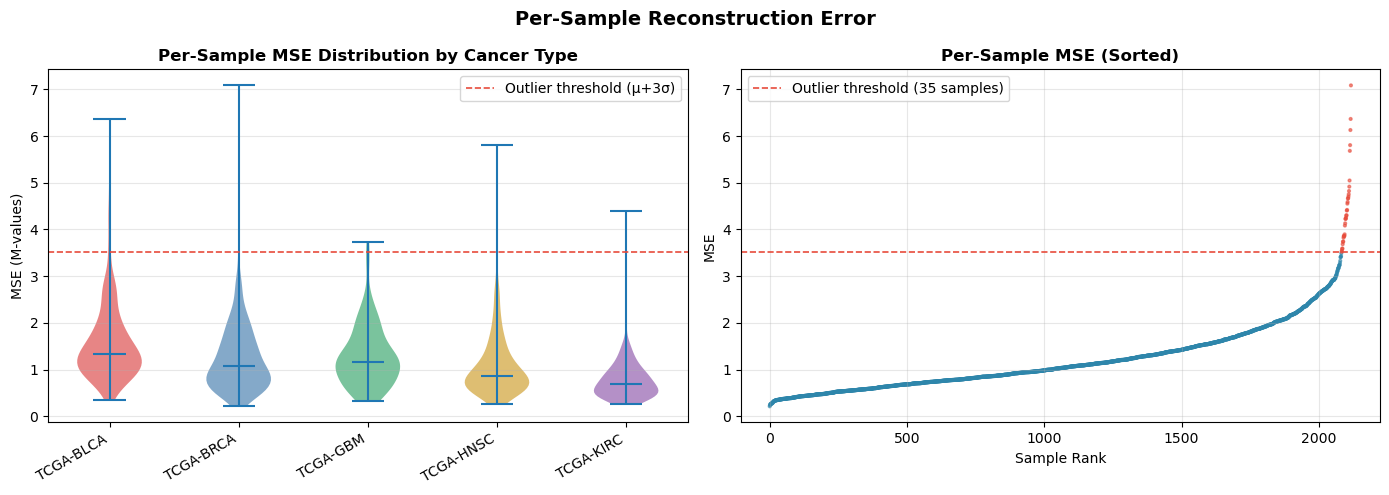


      Figure saved: 1_4_per_sample_mse.png


In [33]:
# --- Figure: per-sample MSE distribution by cancer type ----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Per-Sample Reconstruction Error", fontsize=14, fontweight='bold')
 
# Violin plot
ax = axes[0]
plot_data = pd.DataFrame({'MSE': sample_mse, 'Cancer Type': cancer_labels})
order = sorted(plot_data['Cancer Type'].unique())
parts = ax.violinplot(
    [plot_data[plot_data['Cancer Type'] == ct]['MSE'].values for ct in order],
    positions=range(len(order)), showmedians=True, showextrema=True
)
for i, (pc, ct) in enumerate(zip(parts['bodies'], order)):
    pc.set_facecolor(CANCER_PALETTE.get(ct, '#888888'))
    pc.set_alpha(0.75)
ax.axhline(outlier_threshold, color='#E74C3C', linestyle='--', linewidth=1.2,
           label=f'Outlier threshold (μ+3σ)')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha='right')
ax.set_title("Per-Sample MSE Distribution by Cancer Type", fontweight='bold')
ax.set_ylabel("MSE (M-values)")
ax.legend()
ax.grid(axis='y', alpha=0.3)
 
# Sorted sample MSE with outliers highlighted
ax = axes[1]
sorted_idx = np.argsort(sample_mse)
ax.scatter(range(len(sample_mse)),
           sample_mse[sorted_idx],
           c=['#E74C3C' if m > outlier_threshold else '#2E86AB' for m in sample_mse[sorted_idx]],
           s=4, alpha=0.6)
ax.axhline(outlier_threshold, color='#E74C3C', linestyle='--', linewidth=1.2,
           label=f'Outlier threshold ({n_outliers} samples)')
ax.set_title("Per-Sample MSE (Sorted)", fontweight='bold')
ax.set_xlabel("Sample Rank")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1_4_per_sample_mse.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n      Figure saved: 1_4_per_sample_mse.png")

# 1.5 Per-Probe Reconstruction Error

In [ ]:
# Computes MSE per CpG probe across all samples and examines the distribution
# of probe-level reconstruction errors. Identifies the probes reconstructed
# most and least accurately.
#
# INTERPRETATION:
#   GOOD  — Per-probe MSE follows a right-skewed distribution where the
#           majority of probes have low error and a small tail of probes has
#           higher error. High-error probes should NOT be systematically
#           enriched at known functional regions — if they are, that is a
#           biological fidelity problem addressed in Tier 3.
#   BAD   — A bimodal per-probe MSE distribution suggests the VAE has
#           partitioned the probe space into well-reconstructed and
#           poorly-reconstructed subsets, which indicates a capacity problem
#           in the decoder. Probes with near-zero variance in the raw data
#           will have near-zero MSE trivially — verify that top-accuracy
#           probes are not just invariant probes.

In [34]:
probe_mse = np.mean((X_raw - X_hat) ** 2, axis=0)   # (P,)
probe_mae = np.mean(np.abs(X_raw - X_hat), axis=0)   # (P,)
 
print(f"\n  Per-Probe MSE Summary ({len(probe_mse):,} probes):")
print(f"  Mean   : {probe_mse.mean():.6f}")
print(f"  Std    : {probe_mse.std():.6f}")
print(f"  Median : {np.median(probe_mse):.6f}")
print(f"  95th % : {np.percentile(probe_mse, 95):.6f}")
print(f"  99th % : {np.percentile(probe_mse, 99):.6f}")
print(f"  Max    : {probe_mse.max():.6f}")


  Per-Probe MSE Summary (225,410 probes):
  Mean   : 1.223102
  Std    : 1.024522
  Median : 0.933982
  95th % : 3.168082
  99th % : 5.029879
  Max    : 26.734941


In [35]:
# Top and bottom probes
probe_ids = adata.var_names
top_error_df = pd.DataFrame({
    'probe_id':  probe_ids[np.argsort(probe_mse)[-20:][::-1]],
    'probe_mse': probe_mse[np.argsort(probe_mse)[-20:][::-1]]
})
print(f"\n  Top 20 highest-error probes:")
print(f"  {top_error_df.to_string(index=False)}")


  Top 20 highest-error probes:
    probe_id  probe_mse
cg23057992  26.734941
cg21577651  23.659058
cg16602369  23.257778
cg10554839  23.237583
cg20545544  22.803583
cg08866780  22.604376
cg22621695  20.447199
cg24077454  19.371124
cg12662576  18.122025
cg04571941  18.021267
cg23097686  16.772079
cg04131969  16.362238
cg17375167  14.865182
cg11041161  14.685020
cg04277327  14.322701
cg16316162  12.244052
cg22240348  12.163151
cg13641185  11.954925
cg24634471  11.726378
cg26314531  11.574337


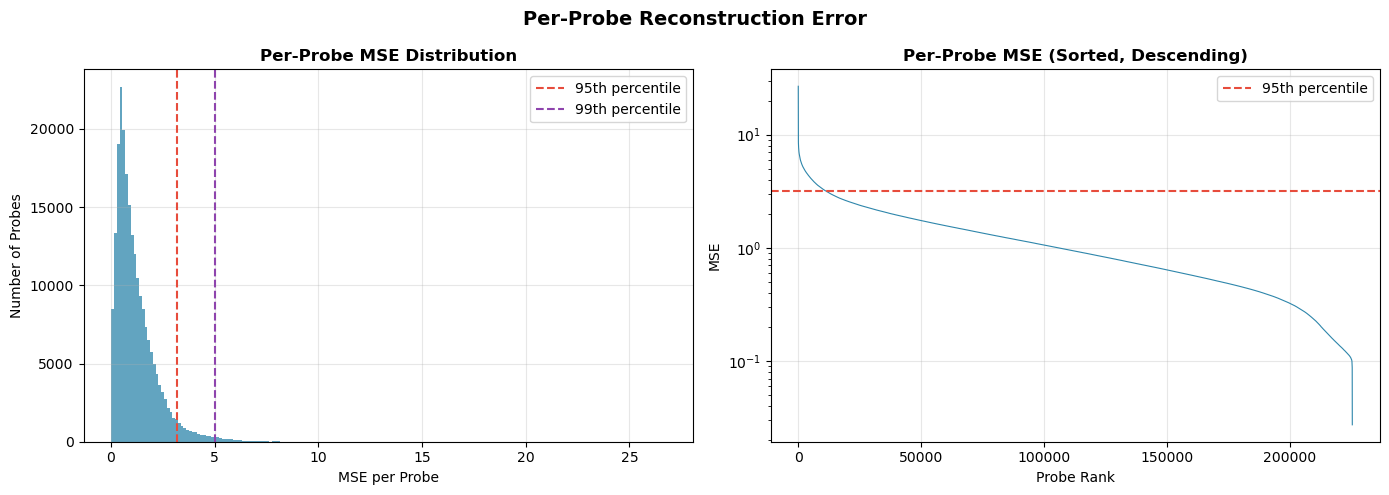


      Figure saved: 1_5_per_probe_mse.png
      Probe MSE saved to probe_mse_tier1.npy (used in Tier 3)


In [36]:
# --- Figure: per-probe MSE distribution --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Per-Probe Reconstruction Error", fontsize=14, fontweight='bold')
 
ax = axes[0]
ax.hist(probe_mse, bins=200, color='#2E86AB', alpha=0.75, edgecolor='none')
ax.axvline(np.percentile(probe_mse, 95), color='#E74C3C', linestyle='--',
           label='95th percentile')
ax.axvline(np.percentile(probe_mse, 99), color='#8E44AD', linestyle='--',
           label='99th percentile')
ax.set_title("Per-Probe MSE Distribution", fontweight='bold')
ax.set_xlabel("MSE per Probe")
ax.set_ylabel("Number of Probes")
ax.legend()
ax.grid(alpha=0.3)
 
ax = axes[1]
sorted_probe_mse = np.sort(probe_mse)[::-1]
ax.plot(range(len(sorted_probe_mse)), sorted_probe_mse, color='#2E86AB', linewidth=0.8)
ax.axhline(np.percentile(probe_mse, 95), color='#E74C3C', linestyle='--',
           label='95th percentile')
ax.set_title("Per-Probe MSE (Sorted, Descending)", fontweight='bold')
ax.set_xlabel("Probe Rank")
ax.set_ylabel("MSE")
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1_5_per_probe_mse.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n      Figure saved: 1_5_per_probe_mse.png")
 
# Save probe MSE for use in Tier 3 (biological fidelity analysis)
np.save("probe_mse_tier1.npy", probe_mse)
print("      Probe MSE saved to probe_mse_tier1.npy (used in Tier 3)")

# 1.6 M-Value Distribution Fidelity

In [ ]:
# Compares the global distribution of M-values before and after reconstruction,
# both globally and stratified by cancer type. Uses Wasserstein distance as a
# distribution-level metric — it penalises both shape and location differences.
#
# INTERPRETATION:
#   GOOD  — Overlapping raw and reconstructed M-value distributions with
#           Wasserstein distance close to zero. The VAE should not be shifting
#           the centre of the distribution or compressing its tails.
#   BAD   — Reconstructed distribution is narrower than raw (variance
#           shrinkage) — a classic posterior collapse signature where the
#           decoder defaults to predicting the mean. Wasserstein distance
#           > 0.5 M-value units is a meaningful distributional shift.
#           Cancer-type specific shifts may indicate the VAE has learned a
#           cancer-agnostic mean and is ignoring cancer-specific signal.

In [37]:
# --- Global Wasserstein distance ----------------------------------------------
# Subsample for speed — 500k values is sufficient for distribution comparison
rng = np.random.default_rng(42)
subsample_idx = rng.choice(X_raw.size, size=min(500_000, X_raw.size), replace=False)
w_dist_global = wasserstein_distance(X_raw.flatten()[subsample_idx],
                                     X_hat.flatten()[subsample_idx])
 
print(f"\n  Global Wasserstein Distance (M-values): {w_dist_global:.6f}")
print(f"  Raw M-value:   mean={X_raw.mean():.4f}, std={X_raw.std():.4f}")
print(f"  Recon M-value: mean={X_hat.mean():.4f}, std={X_hat.std():.4f}")
print(f"  Variance ratio (recon/raw): {X_hat.var()/X_raw.var():.4f}",
      "  [OK]" if 0.85 < X_hat.var()/X_raw.var() < 1.15 else "  [WARNING: variance shift]")


  Global Wasserstein Distance (M-values): 0.135468
  Raw M-value:   mean=-0.7331, std=4.6545
  Recon M-value: mean=-0.7251, std=4.5149
  Variance ratio (recon/raw): 0.9409   [OK]


In [38]:
# --- Per-cancer Wasserstein distances ----------------------------------------
cancer_wdist = {}
for ct in cancer_types:
    idx = np.where(cancer_labels == ct)[0]
    sub_raw = X_raw[idx].flatten()
    sub_hat = X_hat[idx].flatten()
    sub_idx = rng.choice(len(sub_raw), size=min(100_000, len(sub_raw)), replace=False)
    cancer_wdist[ct] = wasserstein_distance(sub_raw[sub_idx], sub_hat[sub_idx])
    print(f"  {ct:<15} Wasserstein: {cancer_wdist[ct]:.6f}")

  TCGA-BLCA       Wasserstein: 0.192850
  TCGA-BRCA       Wasserstein: 0.137776
  TCGA-GBM        Wasserstein: 0.150759
  TCGA-HNSC       Wasserstein: 0.133072
  TCGA-KIRC       Wasserstein: 0.107385


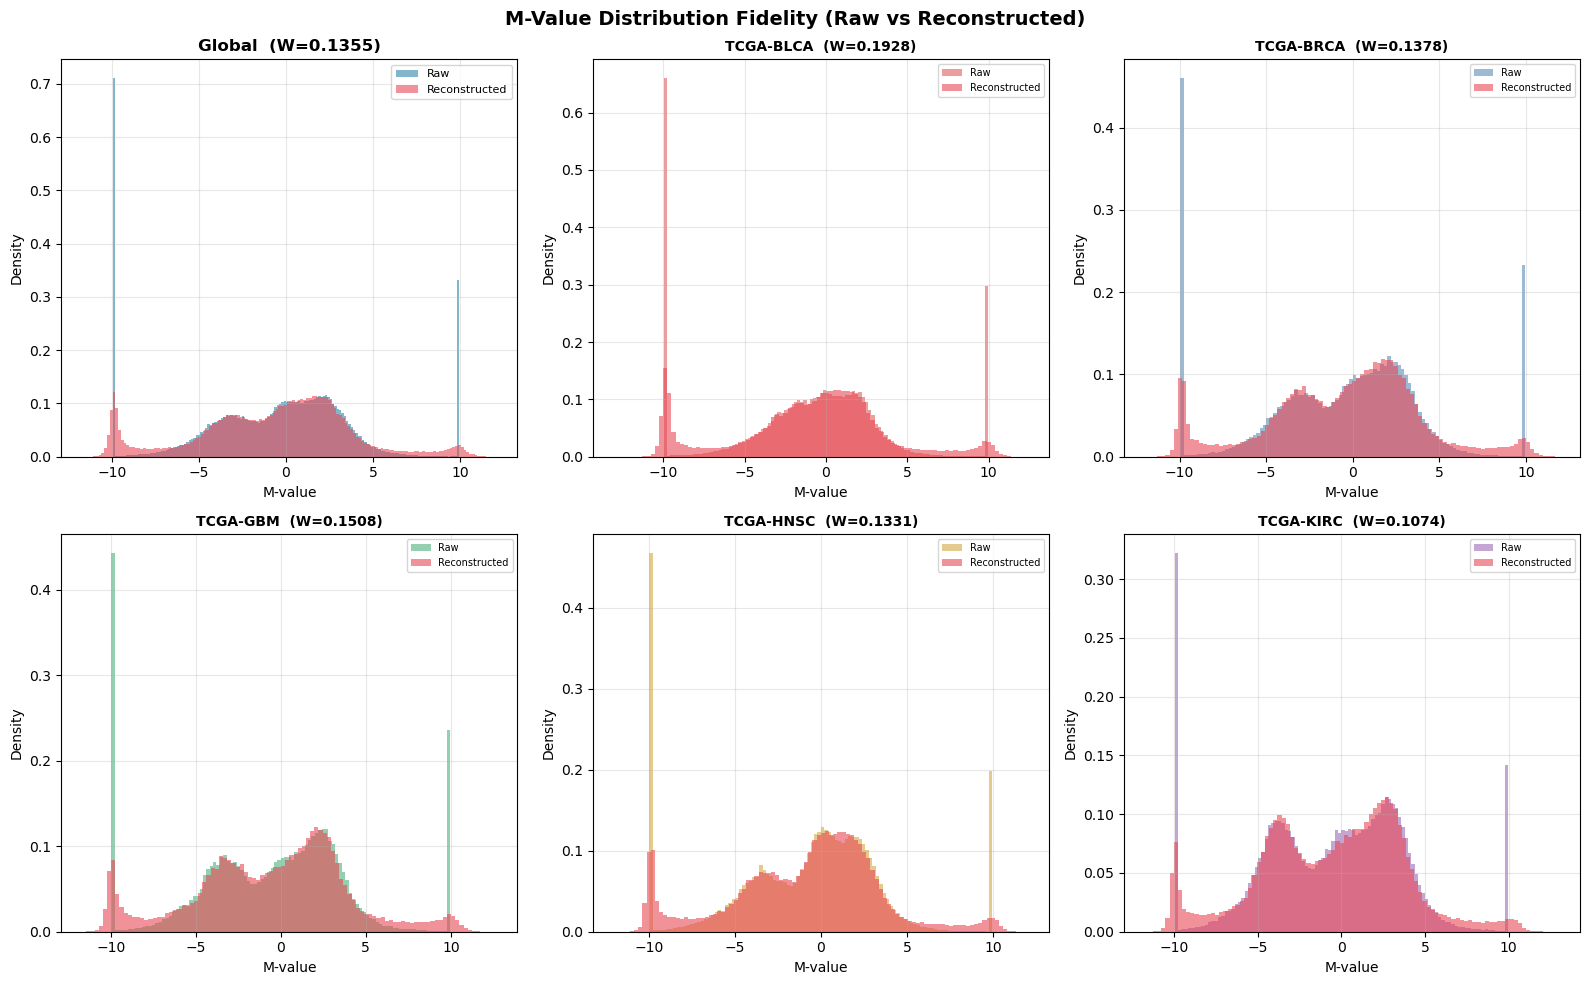


      Figure saved: 1_6_mvalue_distribution_fidelity.png


In [39]:
# --- Figure: distribution overlays -------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("M-Value Distribution Fidelity (Raw vs Reconstructed)",
             fontsize=14, fontweight='bold')
 
# Global distribution
ax = axes[0, 0]
subsample_n = min(200_000, X_raw.size)
ax.hist(X_raw.flatten()[rng.choice(X_raw.size, subsample_n, replace=False)],
        bins=150, alpha=0.6, color='#2E86AB', label='Raw', density=True)
ax.hist(X_hat.flatten()[rng.choice(X_hat.size, subsample_n, replace=False)],
        bins=150, alpha=0.6, color='#E84855', label='Reconstructed', density=True)
ax.set_title(f"Global  (W={w_dist_global:.4f})", fontweight='bold')
ax.set_xlabel("M-value")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
 
# Per-cancer distributions
for i, ct in enumerate(cancer_types):
    row, col = divmod(i + 1, 3)
    if row >= 2: break
    ax = axes[row, col]
    idx = np.where(cancer_labels == ct)[0]
    sub_raw = X_raw[idx].flatten()
    sub_hat = X_hat[idx].flatten()
    sub_n   = min(100_000, len(sub_raw))
    ax.hist(sub_raw[rng.choice(len(sub_raw), sub_n, replace=False)],
            bins=100, alpha=0.6, color=CANCER_PALETTE.get(ct, '#2E86AB'),
            label='Raw', density=True)
    ax.hist(sub_hat[rng.choice(len(sub_hat), sub_n, replace=False)],
            bins=100, alpha=0.6, color='#E84855',
            label='Reconstructed', density=True)
    ax.set_title(f"{ct}  (W={cancer_wdist[ct]:.4f})", fontweight='bold', fontsize=10)
    ax.set_xlabel("M-value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1_6_mvalue_distribution_fidelity.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n      Figure saved: 1_6_mvalue_distribution_fidelity.png")

# 1.7 Bimodal Preservation

In [ ]:
# DNA methylation beta values are functionally bimodal — probes are either
# hypomethylated (β < 0.2) or hypermethylated (β > 0.8) in most biological
# contexts. A common failure mode of VAEs is regression toward the mean,
# which collapses this bimodal structure. This section tests whether the VAE
# preserves the bimodal signature at both the global and per-cancer level.
#
# Uses Hartigan's Dip Test for unimodality — a significant p-value (< 0.05)
# rejects unimodality and supports bimodality.
#
# INTERPRETATION:
#   GOOD  — Beta value distributions show two clear peaks near 0 and 1 in
#           both raw and reconstructed data. Dip test p < 0.05 in both.
#           The valley between peaks (0.3–0.7) should remain low.
#   BAD   — Reconstructed distribution peaks near 0.5 (the mean), indicating
#           the decoder is collapsing to an uninformative average. This would
#           be catastrophic for downstream diffusion model training as it
#           destroys the fundamental signal structure of methylation data.

  Global Dip Test — Raw: stat=0.0625, p=0.0000 | Recon: stat=0.0610, p=0.0000
  TCGA-BLCA       Raw p=0.0000 | Recon p=0.0000
  TCGA-BRCA       Raw p=0.0000 | Recon p=0.0000
  TCGA-GBM        Raw p=0.0000 | Recon p=0.0000
  TCGA-HNSC       Raw p=0.0000 | Recon p=0.0000
  TCGA-KIRC       Raw p=0.0000 | Recon p=0.0000


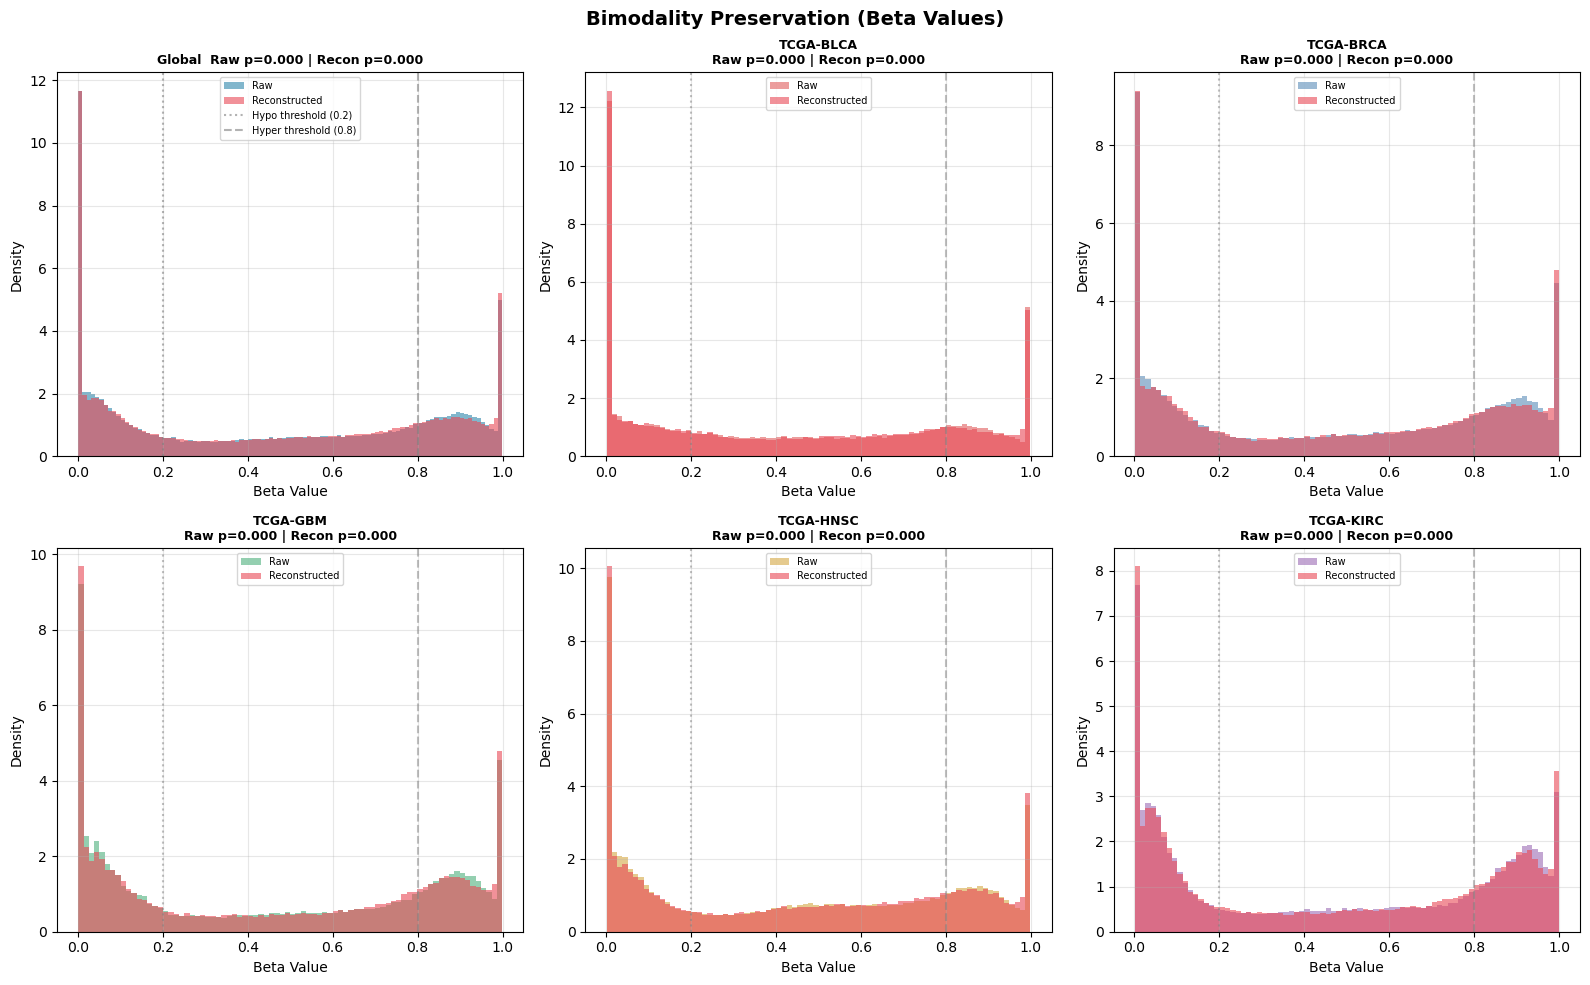


      Figure saved: 1_7_bimodality_preservation.png


In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Bimodality Preservation (Beta Values)", fontsize=14, fontweight='bold')

# Global bimodality
ax = axes[0, 0]
subsample_n = min(200_000, Beta_raw.size)
raw_sub  = Beta_raw.flatten()[rng.choice(Beta_raw.size, subsample_n, replace=False)]
hat_sub  = Beta_hat.flatten()[rng.choice(Beta_hat.size, subsample_n, replace=False)]
ax.hist(raw_sub, bins=100, alpha=0.6, color='#2E86AB', label='Raw', density=True)
ax.hist(hat_sub, bins=100, alpha=0.6, color='#E84855', label='Reconstructed', density=True)
ax.axvline(0.2, color='gray', linestyle=':', alpha=0.6, label='Hypo threshold (0.2)')
ax.axvline(0.8, color='gray', linestyle='--', alpha=0.6, label='Hyper threshold (0.8)')

dip_raw, p_raw = diptest.diptest(raw_sub[:10_000])
dip_hat, p_hat = diptest.diptest(hat_sub[:10_000])
title = f"Global  Raw p={p_raw:.3f} | Recon p={p_hat:.3f}"
print(f"  Global Dip Test — Raw: stat={dip_raw:.4f}, p={p_raw:.4f} | "
      f"Recon: stat={dip_hat:.4f}, p={p_hat:.4f}")

ax.set_title(title, fontweight='bold', fontsize=9)
ax.set_xlabel("Beta Value")
ax.set_ylabel("Density")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
 
# Per-cancer bimodality
for i, ct in enumerate(cancer_types):
    row, col = divmod(i + 1, 3)
    if row >= 2: break
    ax = axes[row, col]
    idx     = np.where(cancer_labels == ct)[0]
    b_raw   = Beta_raw[idx].flatten()
    b_hat   = Beta_hat[idx].flatten()
    sub_n   = min(80_000, len(b_raw))
    b_raw_s = b_raw[rng.choice(len(b_raw), sub_n, replace=False)]
    b_hat_s = b_hat[rng.choice(len(b_hat), sub_n, replace=False)]
    ax.hist(b_raw_s, bins=80, alpha=0.6, color=CANCER_PALETTE.get(ct, '#2E86AB'),
            label='Raw', density=True)
    ax.hist(b_hat_s, bins=80, alpha=0.6, color='#E84855',
            label='Reconstructed', density=True)
    ax.axvline(0.2, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(0.8, color='gray', linestyle='--', alpha=0.5)

    _, p_r = diptest.diptest(b_raw_s[:5000])
    _, p_h = diptest.diptest(b_hat_s[:5000])
    title  = f"{ct}\nRaw p={p_r:.3f} | Recon p={p_h:.3f}"
    print(f"  {ct:<15} Raw p={p_r:.4f} | Recon p={p_h:.4f}")

    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel("Beta Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1_7_bimodality_preservation.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n      Figure saved: 1_7_bimodality_preservation.png")

# 1.8 Methylation State Confusion Matrix

In [ ]:
# Assigns each probe-sample pair a discrete methylation state based on beta
# value thresholds and computes a confusion matrix between raw and reconstructed
# state assignments. This is the most direct test of whether the VAE is
# faithfully preserving the functional methylation state of each probe.
#
# States:
#   Hypomethylated   : β < 0.2
#   Intermediate     : 0.2 ≤ β ≤ 0.8
#   Hypermethylated  : β > 0.8
#
# INTERPRETATION:
#   GOOD  — High diagonal values (>90% agreement for hypo and hyper states).
#           Some spillover into the intermediate class is tolerable. The VAE
#           should rarely flip a hypomethylated probe to hypermethylated or
#           vice versa — these are the most biologically meaningful errors.
#   BAD   — Large off-diagonal values from hypo→intermediate or
#           hyper→intermediate indicate the decoder is pulling probes toward
#           β=0.5. Direct hypo↔hyper flips are the most severe failure.
#           Per-cancer confusion matrices will reveal if this is cancer-type
#           specific.

In [46]:
def assign_state(beta: np.ndarray) -> np.ndarray:
    """Assign methylation state: 0=Hypo, 1=Intermediate, 2=Hyper."""
    state = np.ones(beta.shape, dtype=np.int8)  # Default: intermediate
    state[beta < 0.2] = 0
    state[beta > 0.8] = 2
    return state
 
# Subsample for tractability — 50k random probe-sample pairs
n_sub = min(5_000_000, Beta_raw.size)
flat_idx     = rng.choice(Beta_raw.size, n_sub, replace=False)
states_raw   = assign_state(Beta_raw.flatten()[flat_idx])
states_hat   = assign_state(Beta_hat.flatten()[flat_idx])
 
state_labels = ['Hypo (β<0.2)', 'Intermediate', 'Hyper (β>0.8)']
cm = confusion_matrix(states_raw, states_hat, normalize='true')
 
# Print numeric summary
print(f"\n  Methylation State Confusion Matrix (rows=raw, cols=reconstructed):")
cm_df = pd.DataFrame(cm, index=state_labels, columns=state_labels)
print(f"\n{cm_df.round(4).to_string()}")


  Methylation State Confusion Matrix (rows=raw, cols=reconstructed):

               Hypo (β<0.2)  Intermediate  Hyper (β>0.8)
Hypo (β<0.2)         0.9439        0.0560         0.0001
Intermediate         0.0539        0.8709         0.0752
Hyper (β>0.8)        0.0002        0.1207         0.8791


In [47]:
# Critical transitions
hypo_to_hyper  = cm[0, 2]
hyper_to_hypo  = cm[2, 0]
hypo_to_interm = cm[0, 1]
hyper_to_interm= cm[2, 1]
print(f"\n  Critical error rates:")
print(f"  Hypo  → Hyper  (flip): {hypo_to_hyper:.4f}  {'[OK]' if hypo_to_hyper < 0.01 else '[WARNING]'}")
print(f"  Hyper → Hypo   (flip): {hyper_to_hypo:.4f}  {'[OK]' if hyper_to_hypo < 0.01 else '[WARNING]'}")
print(f"  Hypo  → Interm (pull): {hypo_to_interm:.4f}  {'[OK]' if hypo_to_interm < 0.10 else '[WARNING: mean collapse]'}")
print(f"  Hyper → Interm (pull): {hyper_to_interm:.4f}  {'[OK]' if hyper_to_interm < 0.10 else '[WARNING: mean collapse]'}")


  Critical error rates:
  Hypo  → Hyper  (flip): 0.0001  [OK]
  Hyper → Hypo   (flip): 0.0002  [OK]
  Hypo  → Interm (pull): 0.0560  [OK]
  Hyper → Interm (pull): 0.1207  [WARNING: mean collapse]


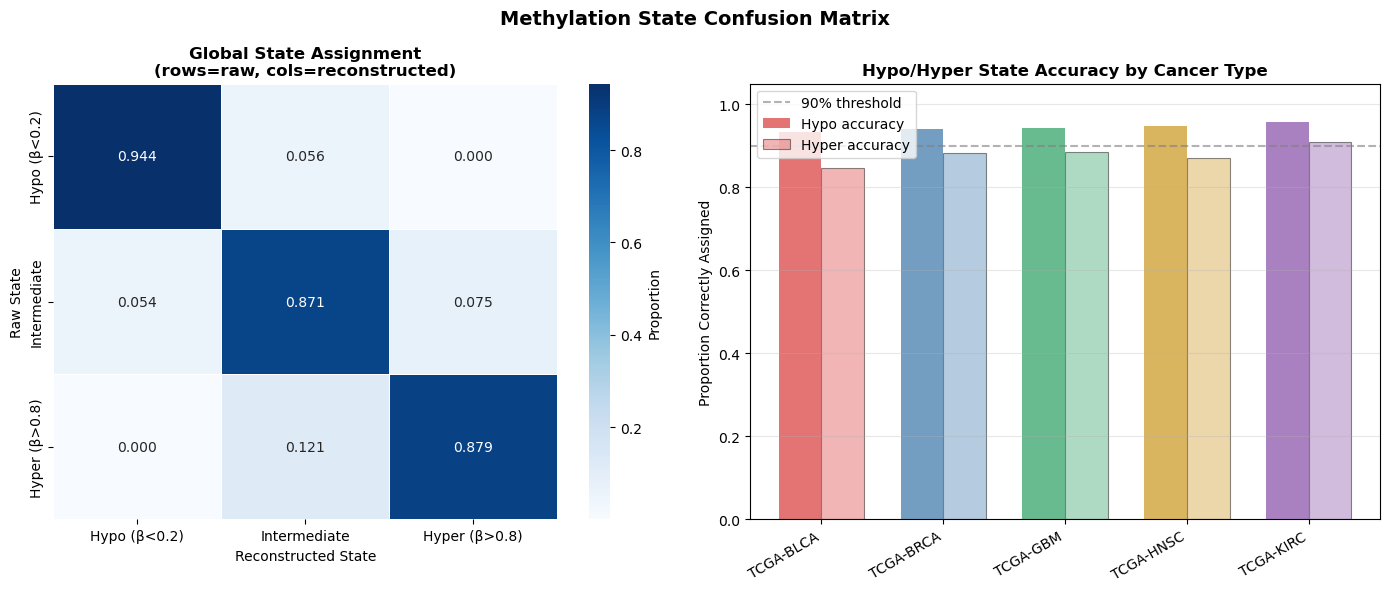


      Figure saved: 1_8_methylation_state_confusion.png


In [48]:
# --- Figure: confusion matrix heatmap ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Methylation State Confusion Matrix", fontsize=14, fontweight='bold')
 
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=state_labels, yticklabels=state_labels,
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Proportion'})
ax.set_title("Global State Assignment\n(rows=raw, cols=reconstructed)", fontweight='bold')
ax.set_ylabel("Raw State")
ax.set_xlabel("Reconstructed State")
 
# Per-cancer state accuracy bar chart
ax = axes[1]
cancer_hypo_acc  = []
cancer_hyper_acc = []
for ct in cancer_types:
    idx     = np.where(cancer_labels == ct)[0]
    sub_n   = min(1_000_000, Beta_raw[idx].size)
    flat_ct = rng.choice(Beta_raw[idx].size, sub_n, replace=False)
    sr = assign_state(Beta_raw[idx].flatten()[flat_ct])
    sh = assign_state(Beta_hat[idx].flatten()[flat_ct])
    cm_ct = confusion_matrix(sr, sh, normalize='true',
                              labels=[0, 1, 2])
    cancer_hypo_acc.append(cm_ct[0, 0])
    cancer_hyper_acc.append(cm_ct[2, 2])
 
x = np.arange(len(cancer_types))
w = 0.35
ax.bar(x - w/2, cancer_hypo_acc,  width=w, label='Hypo accuracy',
       color=[CANCER_PALETTE.get(ct, '#888') for ct in cancer_types], alpha=0.85)
ax.bar(x + w/2, cancer_hyper_acc, width=w, label='Hyper accuracy',
       color=[CANCER_PALETTE.get(ct, '#888') for ct in cancer_types], alpha=0.45,
       edgecolor='black', linewidth=0.8)
ax.axhline(0.90, color='gray', linestyle='--', alpha=0.6, label='90% threshold')
ax.set_xticks(x)
ax.set_xticklabels(cancer_types, rotation=30, ha='right')
ax.set_ylim([0, 1.05])
ax.set_title("Hypo/Hyper State Accuracy by Cancer Type", fontweight='bold')
ax.set_ylabel("Proportion Correctly Assigned")
ax.legend()
ax.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1_8_methylation_state_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n      Figure saved: 1_8_methylation_state_confusion.png")

# 1.9 B Annealing Schedule Verification

In [ ]:
# Reconstructs and verifies the cyclical β annealing schedule as it was
# applied during training. This confirms the schedule behaved as intended
# and contextualises the KL diagnostics in section 1.10.
#
# INTERPRETATION:
#   GOOD  — Clean saw-tooth pattern with the correct number of cycles,
#           reaching β_max at each peak and returning to 0 at each reset.
#           The number of visible cycles should match model.hparams.num_cycles.
#   BAD   — If β never reaches β_max, the training run was too short for
#           the schedule. If the pattern is irregular, check that
#           trainer.estimated_stepping_batches was correct at training time.

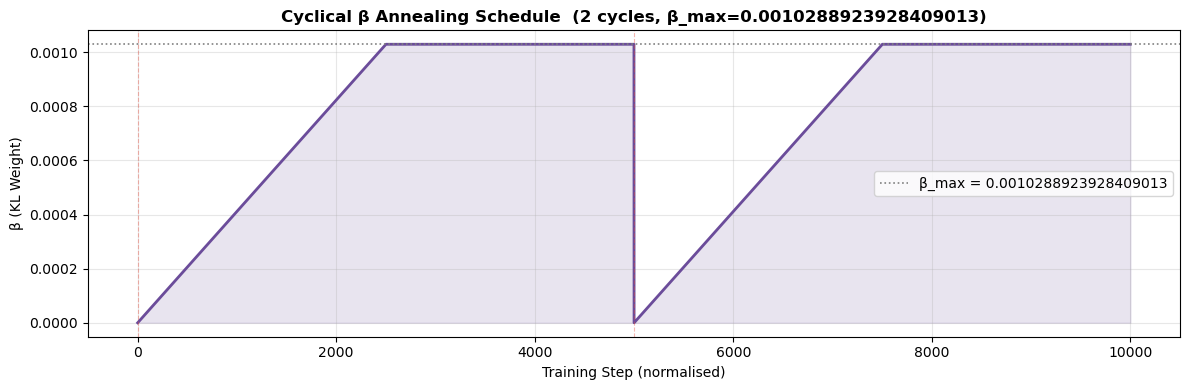


  β_max    : 0.0010288923928409013
  Cycles   : 2
  Schedule : Linear ramp (0 → β_max) over first half of each cycle,
             hold at β_max for second half.

      Figure saved: 1_9_beta_annealing_schedule.png


In [49]:
beta_max   = model.hparams.beta
num_cycles = model.hparams.num_cycles
 
# Reconstruct the theoretical schedule
total_steps = 10_000  # Normalised — shape is what matters
cycle_len   = total_steps / num_cycles
steps       = np.arange(total_steps)
beta_sched  = []
for s in steps:
    cycle_pos = (s % np.ceil(cycle_len)) / cycle_len
    annealed  = min(1.0, cycle_pos * 2.0)
    beta_sched.append(beta_max * annealed)
 
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, beta_sched, color='#6B4C9A', linewidth=2.0)
ax.fill_between(steps, 0, beta_sched, alpha=0.15, color='#6B4C9A')
ax.axhline(beta_max, color='gray', linestyle=':', linewidth=1.2,
           label=f'β_max = {beta_max}')
 
for c in range(num_cycles):
    ax.axvline(c * cycle_len, color='#E74C3C', linestyle='--', alpha=0.4,
               linewidth=0.8)
 
ax.set_title(f"Cyclical β Annealing Schedule  "
             f"({num_cycles} cycles, β_max={beta_max})",
             fontweight='bold')
ax.set_xlabel("Training Step (normalised)")
ax.set_ylabel("β (KL Weight)")
ax.legend()
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1_9_beta_annealing_schedule.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  β_max    : {beta_max}")
print(f"  Cycles   : {num_cycles}")
print(f"  Schedule : Linear ramp (0 → β_max) over first half of each cycle,")
print(f"             hold at β_max for second half.")
print("\n      Figure saved: 1_9_beta_annealing_schedule.png")
 

# 1.10 KL Divergence & Posterior Diagnostics

In [ ]:
# Analyses the posterior distribution learned by the encoder. For each latent
# dimension, computes the mean KL divergence across all samples — a proxy for
# how much information that dimension encodes. Dimensions with near-zero KL
# have collapsed to the prior (uninformative). Dimensions with high KL are
# actively encoding structure from the input.
#
# Also examines the aggregate posterior vs the unit Gaussian prior — a large
# discrepancy indicates the diffusion model will be sampling from a region
# not well covered by the learned posterior, which is directly harmful for
# your downstream pipeline.
#
# INTERPRETATION:
#   GOOD  — A mix of active (KL >> 0) and near-prior (KL ≈ 0) dimensions.
#           With β-VAE and cyclical annealing, some collapse is expected and
#           desirable — not every dimension needs to be active. The aggregate
#           posterior means should be centred near zero, and the aggregate
#           posterior variance should be close to 1.
#   BAD   — All dimensions collapsed to zero KL indicates complete posterior
#           collapse — the encoder is outputting μ=0, σ=1 for every input
#           regardless of content. Aggregate posterior mean far from zero
#           indicates a systematic bias the diffusion model will need to
#           account for. Aggregate posterior variance >> 1 indicates the
#           latent space is over-dispersed relative to the prior.

In [50]:
# Per-dimension KL divergence: KL(q||p) = -0.5 * (1 + logvar - mu^2 - exp(logvar))
per_dim_kl = -0.5 * (1 + Z_logvar - Z_mu**2 - np.exp(Z_logvar))  # (N, L)
mean_kl_per_dim = per_dim_kl.mean(axis=0)   # (L,) — mean KL per dimension
 
# Active dimensions (KL > 0.1 threshold)
KL_THRESHOLD = 0.1
n_active = np.sum(mean_kl_per_dim > KL_THRESHOLD)
print(f"\n  Latent Dimensionality: {model.hparams.latent_dim}")
print(f"  Active dimensions (KL > {KL_THRESHOLD}): {n_active} "
      f"({100*n_active/model.hparams.latent_dim:.1f}%)")
print(f"  Mean KL across all dims : {mean_kl_per_dim.mean():.6f}")
print(f"  Max KL (most active dim): {mean_kl_per_dim.max():.6f}")
print(f"  Min KL (most collapsed) : {mean_kl_per_dim.min():.6f}")


  Latent Dimensionality: 92
  Active dimensions (KL > 0.1): 92 (100.0%)
  Mean KL across all dims : 1.489134
  Max KL (most active dim): 2.821681
  Min KL (most collapsed) : 0.681887


In [51]:
# Aggregate posterior statistics
agg_mu_mean = Z_mu.mean(axis=0)   # Per-dimension mean of posterior means
agg_mu_std  = Z_mu.std(axis=0)    # Per-dimension std of posterior means
agg_var     = np.exp(Z_logvar).mean(axis=0)  # Per-dim mean posterior variance
 
print(f"\n  Aggregate Posterior:")
print(f"  Mean of μ (should be ≈ 0): {agg_mu_mean.mean():.6f}  "
      f"{'[OK]' if abs(agg_mu_mean.mean()) < 0.5 else '[WARNING: posterior bias]'}")
print(f"  Std of μ across dims     : {agg_mu_std.mean():.6f}")
print(f"  Mean σ² (should be ≈ 1) : {agg_var.mean():.6f}  "
      f"{'[OK]' if 0.5 < agg_var.mean() < 2.0 else '[WARNING: variance mismatch]'}")


  Aggregate Posterior:
  Mean of μ (should be ≈ 0): 0.006035  [OK]
  Std of μ across dims     : 0.822684
  Mean σ² (should be ≈ 1) : 0.052956  [WARNING: variance mismatch]


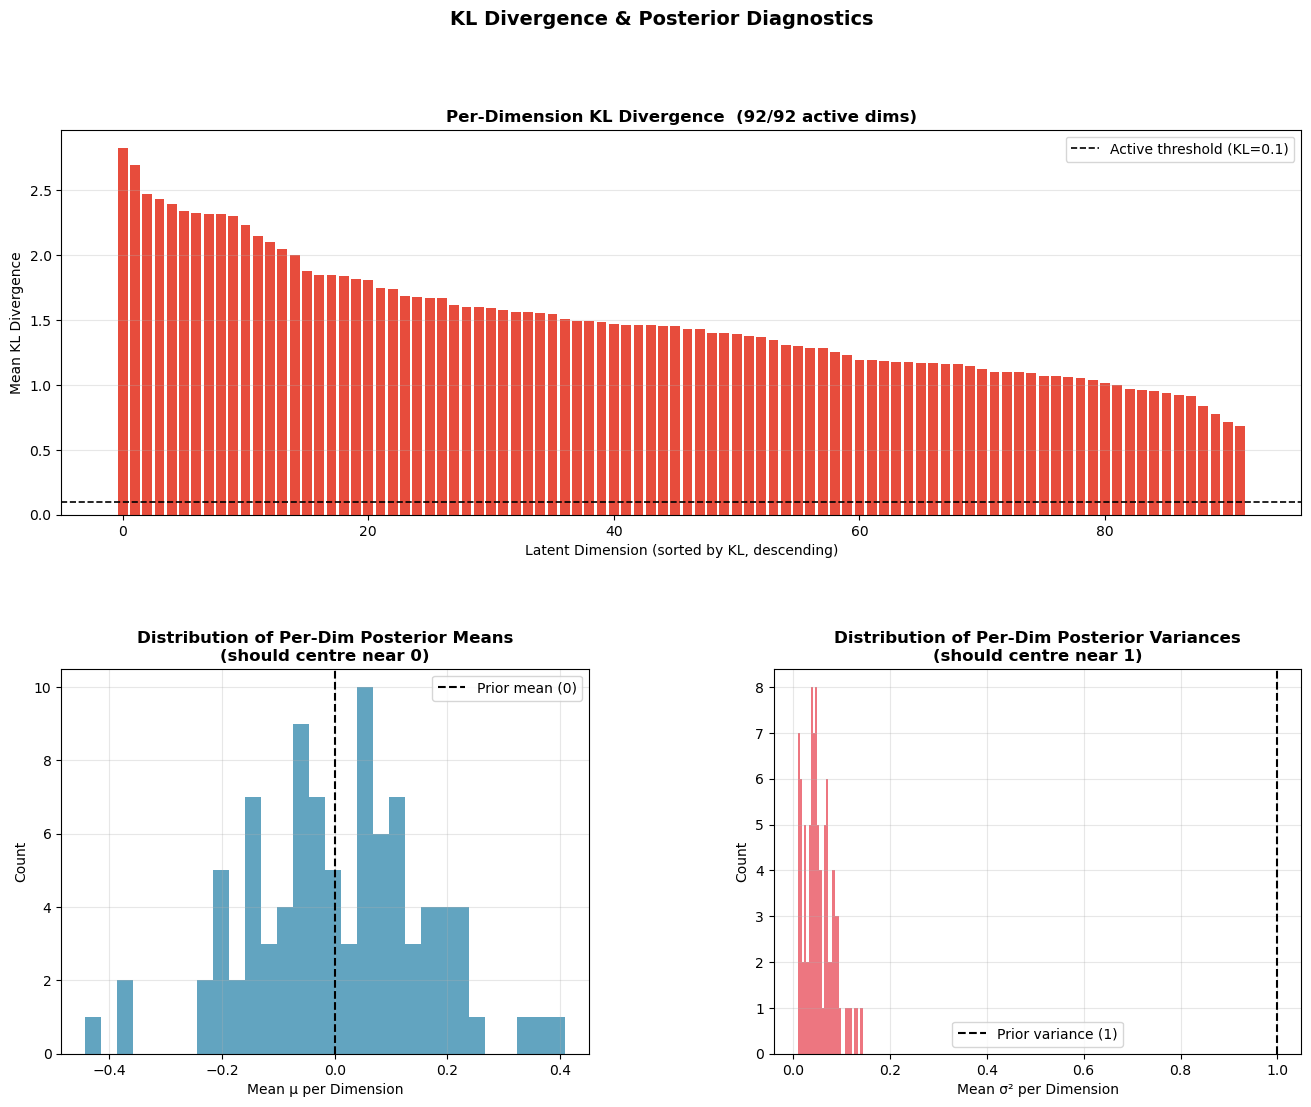


      Figure saved: 1_10_kl_posterior_diagnostics.png


In [54]:
# --- Figure: KL diagnostics ---------------------------------------------------
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("KL Divergence & Posterior Diagnostics", fontsize=14, fontweight='bold')
 
# 1. Per-dimension KL bar chart
ax = fig.add_subplot(gs[0, :])
dim_order = np.argsort(mean_kl_per_dim)[::-1]
colors_kl = ['#E74C3C' if k > KL_THRESHOLD else '#BDC3C7'
              for k in mean_kl_per_dim[dim_order]]
ax.bar(range(len(mean_kl_per_dim)), mean_kl_per_dim[dim_order],
       color=colors_kl, width=0.8)
ax.axhline(KL_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
           label=f'Active threshold (KL={KL_THRESHOLD})')
ax.set_title(f"Per-Dimension KL Divergence  "
             f"({n_active}/{model.hparams.latent_dim} active dims)",
             fontweight='bold')
ax.set_xlabel("Latent Dimension (sorted by KL, descending)")
ax.set_ylabel("Mean KL Divergence")
ax.legend()
ax.grid(axis='y', alpha=0.3)
 
# 2. Aggregate posterior means distribution
ax = fig.add_subplot(gs[1, 0])
ax.hist(agg_mu_mean, bins=30, color='#2E86AB', alpha=0.75, edgecolor='none')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Prior mean (0)')
ax.set_title("Distribution of Per-Dim Posterior Means\n(should centre near 0)",
             fontweight='bold')
ax.set_xlabel("Mean μ per Dimension")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
 
# 3. Aggregate posterior variance distribution
ax = fig.add_subplot(gs[1, 1])
ax.hist(agg_var, bins=30, color='#E84855', alpha=0.75, edgecolor='none')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='Prior variance (1)')
ax.set_title("Distribution of Per-Dim Posterior Variances\n(should centre near 1)",
             fontweight='bold')
ax.set_xlabel("Mean σ² per Dimension")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
 
plt.savefig(FIGURES_DIR / "1_10_kl_posterior_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n      Figure saved: 1_10_kl_posterior_diagnostics.png")

In [55]:
# Save posteriors for downstream tiers
np.save("Z_mu_tier1.npy",     Z_mu)
np.save("Z_logvar_tier1.npy", Z_logvar)
np.save("X_hat_tier1.npy",    X_hat)
np.save("X_raw_tier1.npy",    X_raw)
print("\n  Saved outputs for downstream tiers:")
print("    Z_mu_tier1.npy      — posterior means        (used in Tiers 2, 4, 5)")
print("    Z_logvar_tier1.npy  — posterior log-vars     (used in Tiers 2, 5)")
print("    X_hat_tier1.npy     — reconstructed M-values (used in Tiers 3, 5)")
print("    X_raw_tier1.npy     — raw M-values           (used in Tiers 3, 5)")


  Saved outputs for downstream tiers:
    Z_mu_tier1.npy      — posterior means        (used in Tiers 2, 4, 5)
    Z_logvar_tier1.npy  — posterior log-vars     (used in Tiers 2, 5)
    X_hat_tier1.npy     — reconstructed M-values (used in Tiers 3, 5)
    X_raw_tier1.npy     — raw M-values           (used in Tiers 3, 5)


In [56]:
print("\n" + "=" * 70)
print("TIER 1 SUMMARY")
print("=" * 70)
print(f"""
  Section   Metric                          Value
  -------   ------------------------------  --------------------
  1.3       Global MSE (M-values)           {global_mse:.6f}
  1.3       Global Pearson r                {global_r:.6f}
  1.3       Global R²                       {global_r2:.6f}
  1.6       Wasserstein distance (global)   {w_dist_global:.6f}
  1.6       Variance ratio (recon/raw)      {X_hat.var()/X_raw.var():.4f}
  1.8       Hypo→Hyper flip rate            {hypo_to_hyper:.6f}
  1.8       Hyper→Hypo flip rate            {hyper_to_hypo:.6f}
  1.10      Active latent dimensions        {n_active}/{model.hparams.latent_dim}
  1.10      Aggregate posterior mean        {agg_mu_mean.mean():.6f}
  1.10      Aggregate posterior variance    {agg_var.mean():.6f}
 
  All figures saved to: {FIGURES_DIR}/
  All arrays saved to:  ./  (for use in Tiers 2–5)
""")


TIER 1 SUMMARY

  Section   Metric                          Value
  -------   ------------------------------  --------------------
  1.3       Global MSE (M-values)           1.223103
  1.3       Global Pearson r                0.959298
  1.3       Global R²                       0.943542
  1.6       Wasserstein distance (global)   0.135468
  1.6       Variance ratio (recon/raw)      0.9409
  1.8       Hypo→Hyper flip rate            0.000107
  1.8       Hyper→Hypo flip rate            0.000181
  1.10      Active latent dimensions        92/92
  1.10      Aggregate posterior mean        0.006035
  1.10      Aggregate posterior variance    0.052956

  All figures saved to: /ddn_exa/campbell/sli/methylcdm-project/plots/eval_recon/
  All arrays saved to:  ./  (for use in Tiers 2–5)

